# La$_{2}$CuO$_{4}$

The electronic structure of La$_{2}$CuO$_{4}$ is dominated by strong hybridization between Cu($3d$) and O($2p$) states, placing it in the charge-transfer insulator regime of the Zaanen-Sawatzky-Allen classification diagram. Its most famous role is as the parent compound of high-T$_{c}$ cuprate superconductors, becoming a superconductor upon hole or electron doping. Standard DFT predicts a metallic state because it cannot capture the strong local Coulomb repulsion and charge-transfer gap that arise from the interplay of copper and oxygen orbitals. DFT+DMFT, particularly in a large energy window including both Cu and O states, is essential for describing the experimentally observed insulating behavior, spectral weight transfer, and the multi-orbital nature of the correlations.

In this tutorial, we learn how to write a DMFT calculation for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. Specifically, we will cover
- a OneBodyElementsOnGrid object
- manipulating the embedding object
- the double-counting term in the DMFT loop
- writing the DMFT loop
- plotting the $k$-summed spectral function projected onto different atoms and orbitals.

### 🧪 Exercise 0: Import Modest and Load the DFT data
Load the ``triqs_modest`` module and use the function ``one_body_elements_from_dft_converter`` to load in the HDF5 which was produced by the Wien2k DFT converter in ``ref_data/la2cuo4.h5``.

> 💡 **Tip:** The function ``one_body_elements_from_dft_converter`` returns the target density and the one-body elements.

Print both the target electron density and the one_body_elements and pause for a moment to see if this information makes sense for La$_{2}$CuO$_{4}$.

In [1]:
import triqs_modest as modest

target_density, obe = modest.one_body_elements_from_dft_converter("../ref_data/la2cuo4.h5")
print(f"target_density= {round(target_density)}e- ( 6e- x 4 O + 9e- x 1 Cu = 33e-)\n")
print(obe)

target_density= 33e- ( 6e- x 4 O + 9e- x 1 Cu = 33e-)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 44
      Represented on a fixed grid of 40 points.
      Shape of H[k_idx, σ, ν, ν'] = [40, 1, 44, 44]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 5
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   5
             a:   0
        irreps: [1, 1, 1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [40, 1, 5, 44]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 16
      Number of rotations per op: 1



#### 🔎 Explanation of the OBE

We are studying La$_{2}$CuO$_{4}$ within a large-energy window, which fully includes the hybridization between the O($2p$) and Cu($3d$) states. The ``OneBodyElementsOnGrid`` is composed of four pieces that represent the one-body physics that is obtained from DFT and will be used in the DMFT calculation.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the DFT Kohn-Sham eigenvalues: $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. We created a projector for all five Cu($3d$) orbitals and we indicated that we want to treat this atom as correlated. The following is reflected in the printout '(1) correlated atom with orbital dimension 5'.

##### 🔹 P: Downfolding projector
This is the projector that we introduced in [Tutorial 05](05s-dftdmft.ipynb). Importantly, we print the shape of the projector so that the user can confirm that this is what they expect.

##### 🔹 IBZ: Irreducible Brillouin zone Ops
Some DFT codes perform the summation in the Brillouin zone within the irreducible Brillouin zone. For those cases, to obtain observables like the local Green's function, we must symmetrize. Internally, we read these IBZ symmetry operations and store them away. We apply them whenever we perform a $k$-summation. In practice, there is no need to worry about them 🙂. The 16 symmetry operations correspond to the $I4/mmm$ space group. 

<a id="covalency-into"></a>
## ⚛️ The role of covalency in the metal-insulator transition of La$_{2}$CuO$_{4}$
Our goal is to study La$_{2}$CuO$_{4}$ within DFT+DMFT, where we treat only the Cu-$d_{x^{2}-y^{2}}$ as our quantum impurity which we solve within DMFT. All other states will be treated at the Hartree level within DFT. While we will not study the effects of charge self-consistency, the script that you will develop in the notebook can easily be adapted to perform charge self-consistent calculations.

Within DFT + DMFT, the so-called "double-counting" term plays a critical role in achieving the correct physics. Previously, [Wang et. al.](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.86.195136) calculated the metal-insulator phase diagram for La$_{2}$CuO$_{4}$ in the plane of Hubbard interaction and $N_{d}$ where $N_{d}$ is the total filling of the Cu-$d_{x^{2}-y^{2}}$ orbitals. We will develop a script using TRIQS/ModEST to reproduce the results in Figure 4 (top panel) of their manuscript which correctly captures the insulating behavior of La$_{2}$CuO$_{4}$ but requires an adjustment to the double-counting term.

### 🧪 Exercise 1: Create an Embedding Description
Create an embedding from the local space in one-body elements and print it out to the screen.

In [2]:
E = modest.make_embedding(obe.C_space)
print(E)

Embedding: 1 impurities
  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1   1   1
                      γ =   0   1   2   3   4



Up until now we've only seen rather simple embeddings. However, to see the full information contained within the embedding class, use the ``description`` method to get a full print out.

In [3]:
print(E.description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1   1   1
                      γ =   0   1   2   3   4
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], up_3 [1], up_4 [1], down_0 [1], down_1 [1], down_2 [1], down_3 [1], down_4 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 0, γ = 1, τ = 0)    (imp_idx = 0, γ = 1, τ = 1)  
      α = 2  |   (imp_idx = 0, γ = 2, τ = 0)    (imp_idx = 0, γ = 2, τ = 1)  
      α = 3  |   (imp_idx = 0, γ = 3, τ = 0)    (imp_idx = 0, γ = 3, τ = 1)  
      α = 4  |   (imp_

#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channels. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ used in the impurity model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, there are 5 orbitals each representing a $1\times1$ block in the self-energy (see $\alpha$ and dim_$\alpha$).

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there are 5 correlated orbitals with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **10 blocks**: 5 for spin-up and 5 for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], up_3 [1], up_4 [1], down_0 [1], down_1 [1], down_2 [1], down_3 [1], down_4 [1]
```
This means:
- The impurity solver has **10 blocks**, 5 for each spin,
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mapping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

For this case, the mapping is simple: the five blocks of the impurity self-energy are directly mapped to the five blocks in the embedded self-energy.

### 🧪 Exercise 2: From 5 correlated orbitals to 1 correlated orbital

We constructed a five-orbital correlated subspace for the Cu($3d$) orbitals, which is currently treated as a single correlated impurity. However, one could instead split off certain orbitals to treat them with a different impurity solver or exclude them from the impurity altogether. For example, in Cu$^{2+}$ ($3d^{9}$), the $t_{2g}$ shell is fully filled, so -- at least to first approximation -- correlation effects in this sector are expected to be weak. Furthermore, due to their large octahedral elongation, the $e_{g}$ levels are strongly split, with the $3z^{2}-r^{2}$ orbital lying lower in energy and being filled first, leaving the $d_{x^{2}-y^{2}}$ orbital approximately half-filled and at the Fermi level. 

In this exercise, you will modify the embedding to reflect that we want to solve a single impurity for the Cu $d_{x^{2}-y^{2}}$ orbital, removing the other four orbitals from the impurity. To achieve this, we will use the ``split`` and ``drop`` methods of the ``Embedding`` class. To do this you also need to know the orbital order. The orbital ordering depends on the DFT code, because different DFT codes have different conventions for ordering the $d$ orbitals. For Wien2k, the orbital ordering is: $d_{3z^{2}-r^{2}}$, $d_{x^{2}-y^{2}}$, $d_{xy}$, $d_{xz}$, and $d_{yz}$.

>💡 **Tips:** 
">
"> - The **E.split_imp** function takes two arguments: an impurity index and a list of blocks.
"> 
"> - The **E.drop_imp** function takes the index of an impurity solver to drop from the list. Dropping an impurity solver means that you want to replace the self-energy that it connects to with a zero self-energy.
">
"> - Each method returns a new embedding, so you do not have to worry about accidentally making changes to the underlying embedding ``E`` that we are working with.

#### 🧩 Your Task
1. Use the split method to divide the Embedding into two impurity solvers: 1 for the Cu-$d_{x^{2}-y^{2}}$ and 1 for the remaining 4 orbitals.
```python
E1 = E.split_imp(0, """your answer""")
```
2. Use the drop method to drop the impurity solver that we do not want to keep.
```python
E1.drop_imp("""your answer""")
```
3. String the two operations together.
```python
E2 = E.split_imp(""" """).drop_imp(""" """)

```
4. Lastly, print the new embedding. You should see something like this:
```text
Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |           σ = 0 / up                     σ = 1 / down           
      -------+--------------------------------+-------------------------------+
      α = 1  |    (imp_idx = 0, γ = 0, τ = 0)     (imp_idx = 0, γ = 0, τ = 1)  

```

In [4]:
print(E.split_imp(0, [1]).drop_imp(1).description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1   1   1
        α:   0   1   2   3   4

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |           σ = 0 / up                     σ = 1 / down           
      -------+--------------------------------+-------------------------------+
      α = 1  |    (imp_idx = 0, γ = 0, τ = 0)     (imp_idx = 0, γ = 0, τ = 1)  



## 2️⃣ Double-Counting
Because we are working in a large energy window and have included the O($2p$) and the La($5d$) orbitals implicitly in the calculation, we need to properly incorporate the double-counting term, which controls the relative splitting between the correlated orbitals and the uncorrelated orbitals. For La$_{2}$CuO$_{4}$, which is a charge-transfer insulator, the double-counting term controls the size of the charge-transfer gap -- the energy difference between the Cu($3d$) and the O($2p$) levels. 

#### ❓ Where does the double-counting term appear in the DMFT loop?
The DMFT self-consistency condition is

$$ G_{\mathrm{loc}} \overset{!}{=} G_{\mathrm{imp}},$$
which reads
$$ \sum_{k} P(k)[i\omega_{n} + \mu - H(k) - P^{\dagger}(\Sigma_{\mathrm{imp}}(i\omega_{n})-\Sigma_{\mathrm{DC}})P]^{-1}P^{\dagger}(k) = \frac{1}{ i\omega_{n} - E_{\mathrm{imp}} - \Delta(i\omega_{n})-\Sigma_{\mathrm{imp}}(i\omega_{n})},$$

In the local Green's function, it is important that we must substract off the double-counting term from the self-energy when we embed the self-energy back to the lattice. Now, let's find the definition of the impurity levels $E_{\mathrm{imp}}$. Taking the high-frequency expansion of both sides gives,

$$ \mu - \langle H(k) \rangle_{k} - \Sigma_{\infty} + \Sigma_{\mathrm{DC}}  = - E_{\mathrm{imp}} - \Sigma_{\infty},$$
and solving for $E_{\mathrm{imp}}$ gives

$$ E_{\mathrm{imp}} = \langle H(k) \rangle_{k} -\mu - \Sigma_{\mathrm{DC}}.$$

So the double-counting term appears in two places:

1. The embedded self-energy, $\Sigma_{\mathrm{embed}} = \Sigma_{\mathrm{imp}} - \Sigma_{\mathrm{DC}}$
2. The local impurity levels which are defined as: $E_{\mathrm{imp}} = \langle H(k) \rangle_{k} -\mu - \Sigma_{\mathrm{DC}}$.

## 🧠 DMFT loop

### 🧪 Exercise 3: Write the DMFT loop

The DMFT loop can be written identically to the one that you worked on in the previous tutorials. You will make a slight modification to the static part of the self-energy and the local impurity levels to incorporate the double-counting correctly.

In [5]:
import numpy as np
from triqs.gf import MeshImFreq
from triqs.operators import n
from triqs_tutorials_utils.triqs_cthyb.solver import solve

# Coulomb interaction
U = 14    

# double-counting density
N_d = 1.1 

# Matsubara Mesh
mesh = MeshImFreq(beta = 10.0, S = "Fermion", n_iw = 250)

# load in density and obe
target_density, obe = modest.one_body_elements_from_dft_converter("../ref_data/la2cuo4.h5")

# create embedding
E = modest.make_embedding(obe.C_space).split_imp(0, [1]).drop_imp(1)

# setup-solver parameters (realistic solver parameters: length_cycle = 9000, n_cycles = 9e+6, n_warmup_cycles = 1e+4)
solver_params = dict(length_cycle=100, n_cycles = int(1e+5),
                     n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=24,
                     fit_max_w=28, imag_threshold = 1e-6)

# make an empty self-energy
Sigma_imp_dynamic, Sigma_imp_infty = E.make_zero_imp_self_energies(mesh)[0]

# compute the double-counting and set it equal to the static part of the self-energy
Sigma_DC = U*(N_d - 0.5)
for SH in Sigma_imp_infty: SH += Sigma_DC

# interaction Hamiltonian
h_int = U*n('up_0',0)*n('down_0',0)

# number of DMFT iterations
n_dmft_loops = 2

epsilon_d = E.extract(modest.impurity_levels(obe))[0]

for n_iter in range(n_dmft_loops):

    # 1. subtract the double-counting to computed the embedded self-energy
    Sigma_imp_infty_minus_dc = [block - Sigma_DC for block in Sigma_imp_infty]

    # 2. embed the impurity self-energy
    Sigma_C_dynamic, Sigma_C_infty = E.embed([Sigma_imp_dynamic], [Sigma_imp_infty_minus_dc])

    # 3. find the chemical potential
    mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_infty, verbosity=False)

    # 4. compute the local Green's function
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_infty))[0]

    # 5. Compute the effective impurity levels
    E_imp = [ block - mu - Sigma_DC for block in epsilon_d]

    # 6. Compute hybridization function
    Delta_iw = modest.hybridization(E_imp, Gloc, Sigma_imp_dynamic, Sigma_imp_infty)

    # 7. solve the quantum impurity problem
    solver_results = solve(Delta_iw, E_imp, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # 8. update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_infty = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree

Starting serial run at: 2025-09-01 09:29:29.911960



╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
Δn = |n_lattice - n_impurity| = 0.3705755644727631
-10.4968*c_dag('down_0',0)*c('down_0',0) + -10.4968*c_dag('up_0',0)*c('up_0',0) + 14*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
09:29:31  98% ETA 00:00:00 cycle 985 of 1000
09:29:31 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
09:29:31   0% ETA 00:00:10 cycle 967 of 100000
09:29:33  21% ETA 00:00:07 cycle 21099 of 100000
09:29:35  46% ETA 00:00:05 cycle 46080 of 100000
09:29:39  77% ETA 00:00:02 cycle 77243 of 100000
09:29:41 100% ETA 00:00:00 cycle 99999 of 100000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                   

Execution time: 0.108892 seconds
Execution time: 0.111136 seconds


## 📊 Analyze Results

### 🧪 Exercise 4: Load the converged results

Now that you have your DMFT loop, we provide you with pre-converged results for this calculation at $\beta = 50.0$ 1/eV. Load the converged data from the file ``ref_data/lco-x2y2-Nd=1.1-beta=50.0-U=14.0.h5``. Plot the self-energy and Green's function from the first and last iteration and explain what you see.

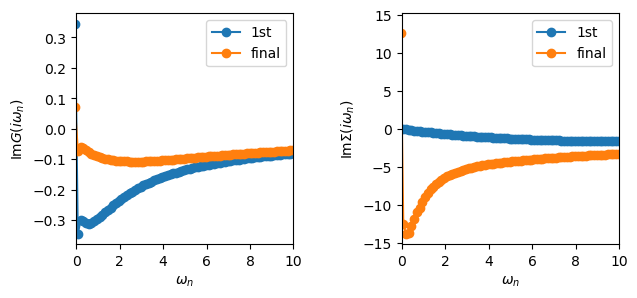

In [6]:
from h5 import HDFArchive

from triqs.plot.mpl_interface import oplot, plt

with HDFArchive('../ref_data/lco-x2y2-Nd=1.1-beta=50.0-U=14.0.h5', 'r') as ar:
    last_iter = str(len(ar)-1)
    Sigma_iw_first = ar['0']['Sigma_imp_list'][0]
    Sigma_iw_last  = ar[last_iter]['Sigma_imp_list'][0]

    G_iw_first = ar['0']['Gimp_freq_list'][0]
    G_iw_last  = ar[last_iter]['Gimp_freq_list'][0]

    mu_last = ar[last_iter]['mu']
    
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
oplot(G_iw_first['up_0'].imag, 'o-', axes=ax[0], label='1st'); 
oplot(G_iw_last['up_0'].imag, 'o-', axes=ax[0], label='final'); ax[0].set_ylabel(r'Im$G(i\omega_{n})$')
oplot(Sigma_iw_first['up_0'].imag, 'o-', axes=ax[1], label='1st'); 
oplot(Sigma_iw_last['up_0'].imag, 'o-', axes=ax[1], label='final'); ax[1].set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax[0].legend(); ax[0].set_xlim(0, 10)
plt.subplots_adjust(wspace=0.5)
plt.show()

At the first iteration, both the Green's function and self-energy indicate metallic behavior. However, at convergence, they both show insulating behavior.

### 🧪 Exercise 5: Analytically continue the self-energy
Now let us analytically continue the self-energy onto the real axis so that we can plot real-frequency spectra. Use the maximum entropy utilities from before to analytically continue the self-energy from the last iteration. Plot your result.

In [7]:
from triqs_tutorials_utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw_last, alpha_min=1e-2, alpha_max=1e2, error=0.04)

Calculating diagonal elements.
Calling MaxEnt for element 0 0


2025-09-01 09:29:53.318087
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.004391421468806407
scaling alpha by a factor 6151 (number of data points)
alpha[ 0] =   6.15100000e+05, chi2 =   2.01199773e+03, n_iter=       4 
alpha[ 1] =   5.09698170e+05, chi2 =   2.00508285e+03, n_iter=       3 


alpha[ 2] =   4.22357705e+05, chi2 =   1.99682641e+03, n_iter=       3 
alpha[ 3] =   3.49983659e+05, chi2 =   1.98698876e+03, n_iter=       3 
alpha[ 4] =   2.90011430e+05, chi2 =   1.97529619e+03, n_iter=       3 
alpha[ 5] =   2.40315876e+05, chi2 =   1.96143969e+03, n_iter=       3 
alpha[ 6] =   1.99136013e+05, chi2 =   1.94507542e+03, n_iter=       3 
alpha[ 7] =   1.65012618e+05, chi2 =   1.92582755e+03, n_iter=       3 
alpha[ 8] =   1.36736514e+05, chi2 =   1.90329441e+03, n_iter=       3 
alpha[ 9] =   1.13305724e+05, chi2 =   1.87705883e+03, n_iter=       3 
alpha[10] =   9.38899692e+04, chi2 =   1.84670341e+03, n_iter=       3 
alpha[11] =   7.78012444e+04, chi2 =   1.81183149e+03, n_iter=       3 
alpha[12] =   6.44694389e+04, chi2 =   1.77209352e+03, n_iter=       3 
alpha[13] =   5.34221346e+04, chi2 =   1.72721802e+03, n_iter=       3 


alpha[14] =   4.42678657e+04, chi2 =   1.67704525e+03, n_iter=       3 
alpha[15] =   3.66822470e+04, chi2 =   1.62156011e+03, n_iter=       3 
alpha[16] =   3.03964789e+04, chi2 =   1.56092022e+03, n_iter=       3 
alpha[17] =   2.51878225e+04, chi2 =   1.49547428e+03, n_iter=       3 
alpha[18] =   2.08717071e+04, chi2 =   1.42576622e+03, n_iter=       3 
alpha[19] =   1.72951893e+04, chi2 =   1.35252202e+03, n_iter=       3 
alpha[20] =   1.43315336e+04, chi2 =   1.27661827e+03, n_iter=       3 
alpha[21] =   1.18757217e+04, chi2 =   1.19903457e+03, n_iter=       3 
alpha[22] =   9.84073098e+03, chi2 =   1.12079455e+03, n_iter=       3 
alpha[23] =   8.15445061e+03, chi2 =   1.04290279e+03, n_iter=       3 
alpha[24] =   6.75712656e+03, chi2 =   9.66285402e+02, n_iter=       3 
alpha[25] =   5.59924409e+03, chi2 =   8.91742041e+02, n_iter=       3 


alpha[26] =   4.63977315e+03, chi2 =   8.19914543e+02, n_iter=       3 
alpha[27] =   3.84471449e+03, chi2 =   7.51274907e+02, n_iter=       3 
alpha[28] =   3.18589488e+03, chi2 =   6.86131845e+02, n_iter=       3 
alpha[29] =   2.63996876e+03, chi2 =   6.24652361e+02, n_iter=       3 
alpha[30] =   2.18759104e+03, chi2 =   5.66892815e+02, n_iter=       3 
alpha[31] =   1.81273150e+03, chi2 =   5.12833058e+02, n_iter=       3 
alpha[32] =   1.50210686e+03, chi2 =   4.62407605e+02, n_iter=       3 
alpha[33] =   1.24470999e+03, chi2 =   4.15529014e+02, n_iter=       4 
alpha[34] =   1.03141994e+03, chi2 =   3.72102574e+02, n_iter=       4 
alpha[35] =   8.54678679e+02, chi2 =   3.32029590e+02, n_iter=       4 


...

alpha[ 3] =   3.49983659e+05, chi2 =   2.23339024e+03, n_iter=       3 
alpha[ 4] =   2.90011430e+05, chi2 =   2.21967500e+03, n_iter=       3 
alpha[ 5] =   2.40315876e+05, chi2 =   2.20343262e+03, n_iter=       3 
alpha[ 6] =   1.99136013e+05, chi2 =   2.18426604e+03, n_iter=       3 
alpha[ 7] =   1.65012618e+05, chi2 =   2.16174306e+03, n_iter=       3 
alpha[ 8] =   1.36736514e+05, chi2 =   2.13540422e+03, n_iter=       3 
alpha[ 9] =   1.13305724e+05, chi2 =   2.10477549e+03, n_iter=       3 
alpha[10] =   9.38899692e+04, chi2 =   2.06938686e+03, n_iter=       3 
alpha[11] =   7.78012444e+04, chi2 =   2.02879725e+03, n_iter=       3 
alpha[12] =   6.44694389e+04, chi2 =   1.98262541e+03, n_iter=       3 
alpha[13] =   5.34221346e+04, chi2 =   1.93058582e+03, n_iter=       3 
alpha[14] =   4.42678657e+04, chi2 =   1.87252678e+03, n_iter=       3 


alpha[15] =   3.66822470e+04, chi2 =   1.80846701e+03, n_iter=       3 
alpha[16] =   3.03964789e+04, chi2 =   1.73862581e+03, n_iter=       3 
alpha[17] =   2.51878225e+04, chi2 =   1.66344127e+03, n_iter=       3 
alpha[18] =   2.08717071e+04, chi2 =   1.58357194e+03, n_iter=       3 
alpha[19] =   1.72951893e+04, chi2 =   1.49987855e+03, n_iter=       3 
alpha[20] =   1.43315336e+04, chi2 =   1.41338567e+03, n_iter=       3 
alpha[21] =   1.18757217e+04, chi2 =   1.32522578e+03, n_iter=       3 
alpha[22] =   9.84073098e+03, chi2 =   1.23657181e+03, n_iter=       3 
alpha[23] =   8.15445061e+03, chi2 =   1.14856618e+03, n_iter=       3 
alpha[24] =   6.75712656e+03, chi2 =   1.06225517e+03, n_iter=       3 
alpha[25] =   5.59924409e+03, chi2 =   9.78536550e+02, n_iter=       3 
alpha[26] =   4.63977315e+03, chi2 =   8.98126134e+02, n_iter=       3 


alpha[27] =   3.84471449e+03, chi2 =   8.21545527e+02, n_iter=       3 
alpha[28] =   3.18589488e+03, chi2 =   7.49129835e+02, n_iter=       3 
alpha[29] =   2.63996876e+03, chi2 =   6.81051219e+02, n_iter=       3 
alpha[30] =   2.18759104e+03, chi2 =   6.17352286e+02, n_iter=       3 
alpha[31] =   1.81273150e+03, chi2 =   5.57982811e+02, n_iter=       3 
alpha[32] =   1.50210686e+03, chi2 =   5.02833769e+02, n_iter=       4 
alpha[33] =   1.24470999e+03, chi2 =   4.51766288e+02, n_iter=       4 
alpha[34] =   1.03141994e+03, chi2 =   4.04629013e+02, n_iter=       4 
alpha[35] =   8.54678679e+02, chi2 =   3.61269343e+02, n_iter=       4 
alpha[36] =   7.08223310e+02, chi2 =   3.21535732e+02, n_iter=       4 


alpha[37] =   5.86864128e+02, chi2 =   2.85275289e+02, n_iter=       4 
alpha[38] =   4.86300718e+02, chi2 =   2.52329496e+02, n_iter=       4 
alpha[39] =   4.02969575e+02, chi2 =   2.22530715e+02, n_iter=       4 
alpha[40] =   3.33917826e+02, chi2 =   1.95701074e+02, n_iter=       4 
alpha[41] =   2.76698593e+02, chi2 =   1.71653954e+02, n_iter=       4 
alpha[42] =   2.29284290e+02, chi2 =   1.50197198e+02, n_iter=       4 
alpha[43] =   1.89994770e+02, chi2 =   1.31136695e+02, n_iter=       4 
alpha[44] =   1.57437793e+02, chi2 =   1.14279273e+02, n_iter=       4 
alpha[45] =   1.30459689e+02, chi2 =   9.94346137e+01, n_iter=       4 


alpha[46] =   1.08104479e+02, chi2 =   8.64165238e+01, n_iter=       4 
alpha[47] =   8.95799949e+01, chi2 =   7.50441948e+01, n_iter=       4 
alpha[48] =   7.42298153e+01, chi2 =   6.51437798e+01, n_iter=       4 
alpha[49] =   6.15100000e+01, chi2 =   5.65502693e+01, n_iter=       4 
MaxEnt loop finished in 0:00:00.997192
appending
Calculating off-diagonal elements using default model from diagonal solution


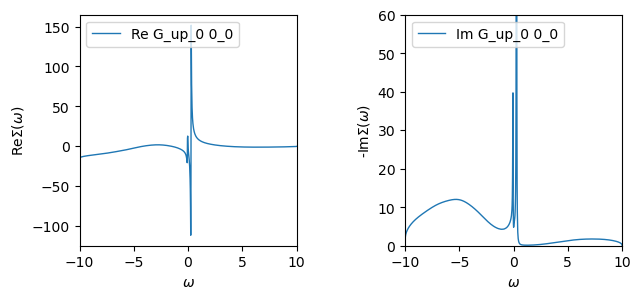

In [8]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
oplot(Sigma_w['up_0'] -Sigma_w['up_0'][0,0](0.0).real, axes=ax[0], mode='R', lw=1)
oplot(-Sigma_w['up_0'].imag, axes=ax[1], lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-10,10); ax[1].set_ylim(0, 60); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 6: Compute real-frequency spectra
Now we will learn how to plot the atom- and orbital-resolved spectral function -- the interacting density of states. The quantity that we want to compute is

$$ A_{\mathrm{proj}}(\omega) = \frac{-1}{\pi} \mathrm{Im} G_{\mathrm{proj}}(\omega), $$

where $G_{\mathrm{proj}}$ is the local Green's function projected onto atom $a$ and orbital $o$. To project the Green's function onto non-correlated orbitals, we need to load new projectors (referred to as $\Theta$ projectors), which span a larger space in the correlated space. The $\Theta$ projectors can then be used to project the lattice Green's function onto specific atoms and orbitals. To post-process your results, follow the steps below.

#### 🧩 Your Task
1. Load in a new one-body elements using the function: ``one_body_elements_with_theta_projectors``. Print out the new obe and try to spot any differences.
2. Embed your real-frequency self-energy using the Embedding (E).
3. Use the function ``projected_spectral_function`` to compute $A_{\mathrm{proj}}(\omega)$.
4. Plot your result.

In [9]:
# 1. load in new obe with Θ projectors
obe_proj = modest.one_body_elements_with_theta_projectors('../ref_data/la2cuo4.h5', obe)
print(obe_proj)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 44
      Represented on a fixed grid of 40 points.
      Shape of H[k_idx, σ, ν, ν'] = [40, 1, 44, 44]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 27
      Number of correlated atoms: 7
      Number of inequivalent correlated atoms = 4
      Atomic decomposition:
         dim_a:   5   5   5   3   3   3   3
             a:   0   1   2   3   4   5   6
        irreps: [5] [5] [1, 1, 1, 1, 1] [3] [3] [3] [3]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [40, 1, 27, 44]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 16
      Number of rotations per op: 

In [10]:
# 2. embed the self-energy minus the double-counting
Sigma_w_proj = E.embed([Sigma_w - Sigma_DC])

In [11]:
# 3. compute the projected spectral function
A_proj = modest.projected_spectral_function(obe_proj, obe.P, mu_last, Sigma_w_proj, broadening=0.05)

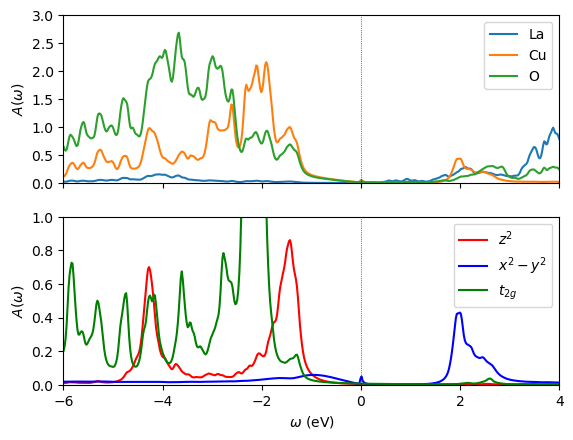

In [12]:
# 4. plot your results.
La = A_proj.per_theta[0,:,:10, :10].trace(axis1=1,axis2=2)
Cu = A_proj.per_theta[0,:,10:15,10:15].trace(axis1=1,axis2=2)
O  = A_proj.per_theta[0,:,16:, 16:].trace(axis1=1,axis2=2)

mesh = np.fromiter(Sigma_w_proj['0','up'].mesh, float)

fig, ax = plt.subplots(2,1,sharex=True)
ax[0].plot(mesh, La.real, label= "La")
ax[0].plot(mesh, Cu.real, label= "Cu")
ax[0].plot(mesh, O.real,  label= "O")
ax[0].set_ylim(0,3); ax[0].legend(); ax[0].axvline(0.0, color='k', ls='dotted', lw=0.5); ax[0].set_ylabel(r'$A(\omega)$')

ax[1].plot(mesh,   A_proj.per_theta[0,:,10,10].real, color='red',   label=r'$z^{2}$')
ax[1].plot(mesh,   A_proj.per_theta[0,:,11,11].real, color='blue',  label=r'$x^{2}-y^{2}$')
ax[1].plot(mesh, 3*A_proj.per_theta[0,:,12,12].real, color='green', label=r'$t_{2g}$')
ax[1].set_ylim(0,2); ax[1].legend(); ax[1].axvline(0.0, color='k', ls='dotted', lw=0.5); ax[1].set_ylabel(r'$A(\omega)$')
ax[1].set_xlim(-6, 4); ax[1].set_ylim(0,1)
ax[1].set_xlabel(r'$\omega$ (eV)')
plt.show()